Gerando a animação com parede em x=0...
Pronto! Arquivo 'massa_mola_amortecedor_x0.gif' salvo.


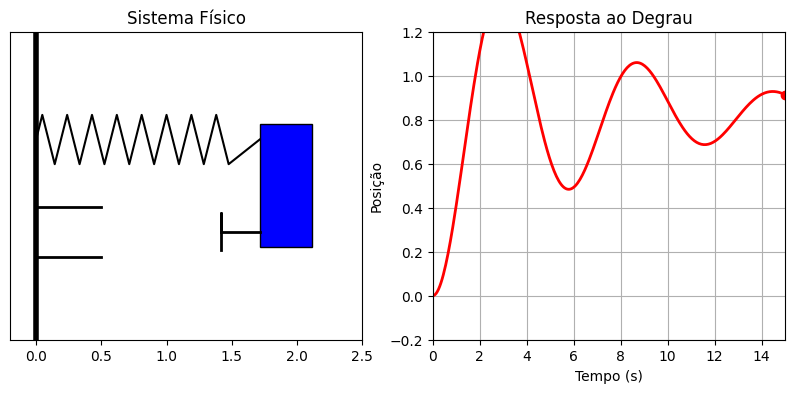

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from scipy.integrate import odeint

# 1. Parâmetros do Sistema
m, c, k = 1.0, 0.3, 1.2
F_degrau = 1.0
y0 = [0.0, 0.0]

# 2. Equação Diferencial
def sistema(y, t):
    x, v = y
    return [v, (F_degrau - c*v - k*x) / m]

# 3. Simulação no tempo
t = np.linspace(0, 15, 300)
sol = odeint(sistema, y0, t)
x_pos = sol[:, 0]

# 4. Funções para desenhar componentes mecânicos
x_parede = 0.0
L_repouso = 1.0  # Distância visual de equilíbrio para não sobrepor a parede
L_massa = 0.4

def get_mola(x_centro_massa, y_pos):
    x_face_massa = x_centro_massa - L_massa/2
    x_pts, y_pts = [x_parede], [y_pos]
    L = x_face_massa - x_parede
    n_voltas = 8
    passo = L / (n_voltas + 1)
    
    for i in range(n_voltas):
        x_pts.extend([x_parede + passo * (i + 0.25), x_parede + passo * (i + 0.75)])
        y_pts.extend([y_pos + 0.08, y_pos - 0.08])
        
    x_pts.append(x_face_massa)
    y_pts.append(y_pos)
    return x_pts, y_pts

def get_amortecedor(x_centro_massa, y_pos):
    x_face_massa = x_centro_massa - L_massa/2
    L_cilindro = 0.5
    x_cabeca_pistao = x_face_massa - 0.3 
    
    # Cilindro (preso na parede)
    cx = [x_parede, x_parede, x_parede+L_cilindro, np.nan, x_parede, x_parede+L_cilindro]
    cy = [y_pos-0.08, y_pos+0.08, y_pos+0.08, np.nan, y_pos-0.08, y_pos-0.08]
    
    # Pistão (preso na massa)
    px = [x_face_massa, x_cabeca_pistao, x_cabeca_pistao, x_cabeca_pistao]
    py = [y_pos, y_pos, y_pos+0.06, y_pos-0.06]
    
    return cx, cy, px, py

# 5. Configuração da Figura
fig, (ax_fisica, ax_grafico) = plt.subplots(1, 2, figsize=(10, 4))

# Eixo 1: Animação Física
ax_fisica.set_xlim(-0.2, 2.5) # Limites estendidos para a direita
ax_fisica.set_ylim(-0.5, 0.5)
ax_fisica.set_title("Sistema Físico")
ax_fisica.get_yaxis().set_visible(False)
ax_fisica.axvline(x=x_parede, color='black', lw=4) # Parede fixada em 0

massa = patches.Rectangle((0, 0), L_massa, L_massa, fc='blue', ec='black')
ax_fisica.add_patch(massa)
linha_mola, = ax_fisica.plot([], [], 'k-', lw=1.5)
linha_cil, = ax_fisica.plot([], [], 'k-', lw=2)
linha_pist, = ax_fisica.plot([], [], 'k-', lw=2)

# Eixo 2: Gráfico
ax_grafico.set_xlim(0, 15)
ax_grafico.set_ylim(-0.2, 1.2)
ax_grafico.set_title("Resposta ao Degrau")
ax_grafico.set_xlabel("Tempo (s)")
ax_grafico.set_ylabel("Posição")
ax_grafico.grid(True)
linha_grafico, = ax_grafico.plot([], [], lw=2, color='red')
ponto_atual, = ax_grafico.plot([], [], 'ro')

# 6. Atualização
def init():
    return massa, linha_mola, linha_cil, linha_pist, linha_grafico, ponto_atual

def update(frame):
    # Deslocamento x(t) somado à posição de repouso visual
    x_visual = L_repouso + x_pos[frame]
    
    # Atualiza Massa
    massa.set_xy((x_visual - L_massa/2, -L_massa/2))
    
    # Atualiza Mola e Amortecedor referenciando a nova posição visual
    mx, my = get_mola(x_visual, 0.15)
    linha_mola.set_data(mx, my)
    
    cx, cy, px, py = get_amortecedor(x_visual, -0.15)
    linha_cil.set_data(cx, cy)
    linha_pist.set_data(px, py)
    
    # Gráfico continua plotando x_pos (começando em 0)
    linha_grafico.set_data(t[:frame], x_pos[:frame])
    ponto_atual.set_data([t[frame]], [x_pos[frame]])
    
    return massa, linha_mola, linha_cil, linha_pist, linha_grafico, ponto_atual

ani = animation.FuncAnimation(fig, update, frames=len(t), init_func=init, blit=True, interval=50)

print("Gerando a animação com parede em x=0...")
ani.save('massa_mola_amortecedor_x0.gif', writer='pillow', fps=20)
print("Pronto! Arquivo 'massa_mola_amortecedor_x0.gif' salvo.")